In [53]:
# Libraries for Data Manipulation
import pandas as pd
import numpy as np

# Libraries for Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
trump_df = pd.read_csv('./data/hashtag_donaldtrump.csv', lineterminator='\n')
biden_df = pd.read_csv('./data/hashtag_joebiden.csv', lineterminator='\n')

In [5]:
# Check shape of both data frames

print(trump_df.shape) # trump_df has more rows by ~200,000

print(biden_df.shape)

(970919, 21)
(776886, 21)


In [28]:
# Check the Info of dataset

print(trump_df.info())
print(biden_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 970919 entries, 0 to 970918
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   created_at            970919 non-null  object 
 1   tweet_id              970919 non-null  float64
 2   tweet                 970919 non-null  object 
 3   likes                 970919 non-null  float64
 4   retweet_count         970919 non-null  float64
 5   source                970043 non-null  object 
 6   user_id               970919 non-null  float64
 7   user_name             970903 non-null  object 
 8   user_screen_name      970919 non-null  object 
 9   user_description      869653 non-null  object 
 10  user_join_date        970919 non-null  object 
 11  user_followers_count  970919 non-null  float64
 12  user_location         675966 non-null  object 
 13  lat                   445719 non-null  float64
 14  long                  445719 non-null  float64
 15  

In [7]:
# Concat two datasets for easier analysis
trump_df['Candidate'] = "TRUMP"
biden_df['Candidate'] = "BIDEN"

mixed_df = pd.concat([trump_df, biden_df])
mixed_df.sort_values(by='created_at')
mixed_df.head()

,created_at,tweet_id,tweet,likes,retweet_count,source,user_id,user_name,user_screen_name,user_description,...,user_location,lat,long,city,country,continent,state,state_code,collected_at,Candidate
0,2020-10-15 00:00:01,1.316529e+18,#Elecciones2020 | En #Florida: #JoeBiden dice ...,0.0,0.0,TweetDeck,3.606665e+08,El Sol Latino News,elsollatinonews,🌐 Noticias de interés para latinos de la costa...,...,"Philadelphia, PA / Miami, FL",25.774270,-80.193660,NaN,United States of America,North America,Florida,FL,2020-10-21 00:00:00,TRUMP
1,2020-10-15 00:00:01,1.316529e+18,"Usa 2020, Trump contro Facebook e Twitter: cop...",26.0,9.0,Social Mediaset,3.316176e+08,Tgcom24,MediasetTgcom24,Profilo ufficiale di Tgcom24: tutte le notizie...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020-10-21 00:00:00.373216530,TRUMP
2,2020-10-15 00:00:02,1.316529e+18,"#Trump: As a student I used to hear for years,...",2.0,1.0,Twitter Web App,8.436472e+06,snarke,snarke,"Will mock for food! Freelance writer, blogger,...",...,Portland,45.520247,-122.674195,Portland,United States of America,North America,Oregon,OR,2020-10-21 00:00:00.746433060,TRUMP
3,2020-10-15 00:00:02,1.316529e+18,2 hours since last tweet from #Trump! Maybe he...,0.0,0.0,Trumpytweeter,8.283556e+17,Trumpytweeter,trumpytweeter,"If he doesn't tweet for some time, should we b...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020-10-21 00:00:01.119649591,TRUMP
4,2020-10-15 00:00:08,1.316529e+18,You get a tie! And you get a tie! #Trump ‘s ra...,4.0,3.0,Twitter for iPhone,4.741380e+07,Rana Abtar - رنا أبتر,Ranaabtar,"Washington Correspondent, Lebanese-American ,c...",...,Washington DC,38.894992,-77.036558,Washington,United States of America,North America,District of Columbia,DC,2020-10-21 00:00:01.492866121,TRUMP


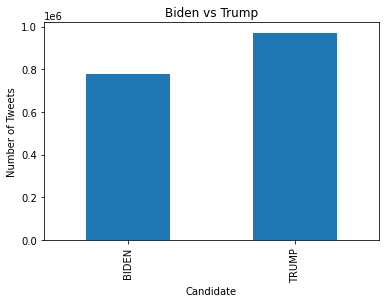

In [17]:
# Plotting the number of tweets for Trump and Biden
mixed_df.groupby('Candidate')['tweet'].count().plot.bar()
plt.title("Biden vs Trump")
plt.ylabel("Number of Tweets")
plt.show()

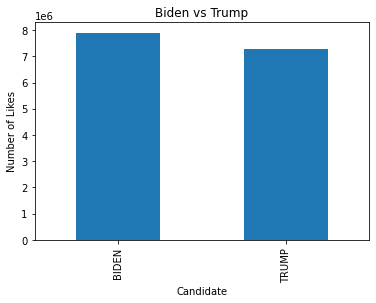

In [20]:
# Comparison of Likes
mixed_df.groupby('Candidate')['likes'].sum().plot.bar()
plt.title("Biden vs Trump")
plt.ylabel("Number of Likes")
plt.show()

In [25]:
# Showing number of Tweets from each country
mixed_df['country'] = mixed_df['country'].replace({"United States of America": "US", "United States": "US"})
mixed_df['country'].value_counts()

US                          394400
United Kingdom               58051
India                        40091
Germany                      35379
France                       35299
                             ...  
Mali                             2
Northern Mariana Islands         1
Saint Lucia                      1
Lesotho                          1
East Timor                       1
Name: country, Length: 188, dtype: int64

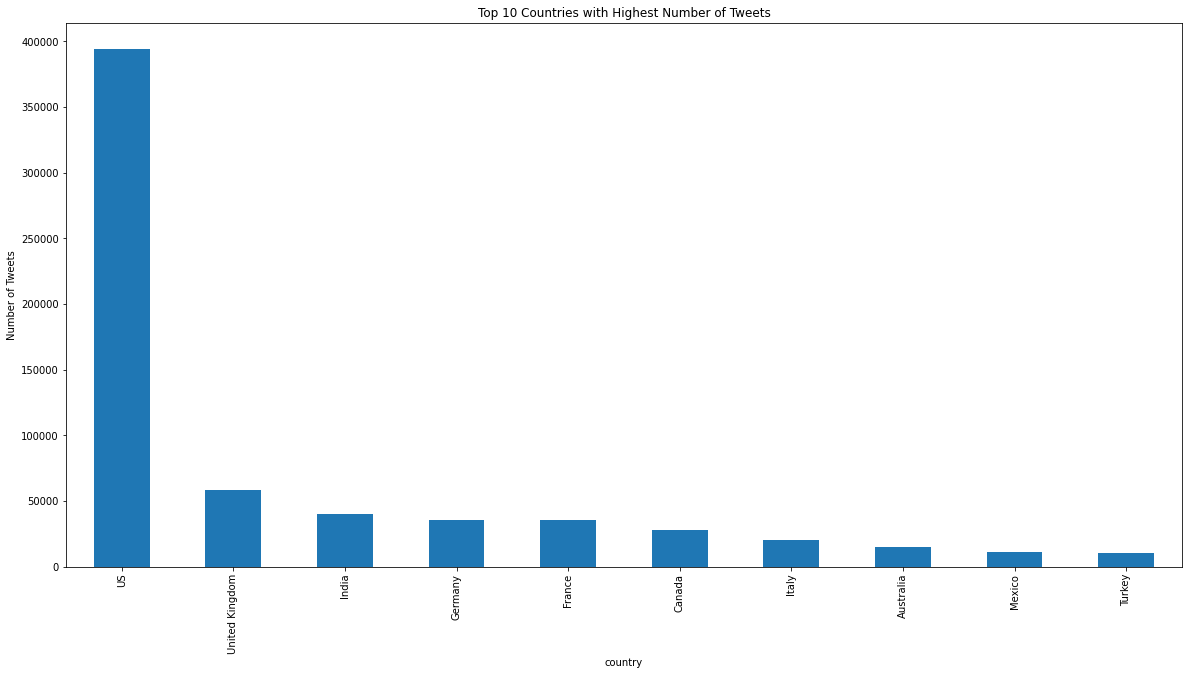

In [26]:
# Comparing number of Tweets from countries
plt.figure(figsize=(20,10))
mixed_df.groupby('country')['tweet'].count().sort_values(ascending=False).head(10).plot.bar()
plt.ylabel('Number of Tweets')
plt.title('Top 10 Countries with Highest Number of Tweets')
plt.show()




In [44]:
# List of Top 10 Countries with highest number of Tweets
top10Countries = mixed_df.groupby('country')['tweet'].count().sort_values(ascending=False).head(10).index.tolist()
top10Countries

['US',
 'United Kingdom',
 'India',
 'Germany',
 'France',
 'Canada',
 'Italy',
 'Australia',
 'Mexico',
 'Turkey']

In [47]:
# Showing Tweets for each candidate from each top 10 country 
tweet_df = mixed_df.groupby(['country', 'Candidate'])['tweet'].count().reset_index()
tweet_df = tweet_df[tweet_df['country'].isin(top10Countries)]
tweet_df

,country,Candidate,tweet
16,Australia,BIDEN,5534
17,Australia,TRUMP,9365
54,Canada,BIDEN,10809
55,Canada,TRUMP,16996
112,France,BIDEN,14610
113,France,TRUMP,20689
118,Germany,BIDEN,12761
119,Germany,TRUMP,22618
146,India,BIDEN,21532
147,India,TRUMP,18559


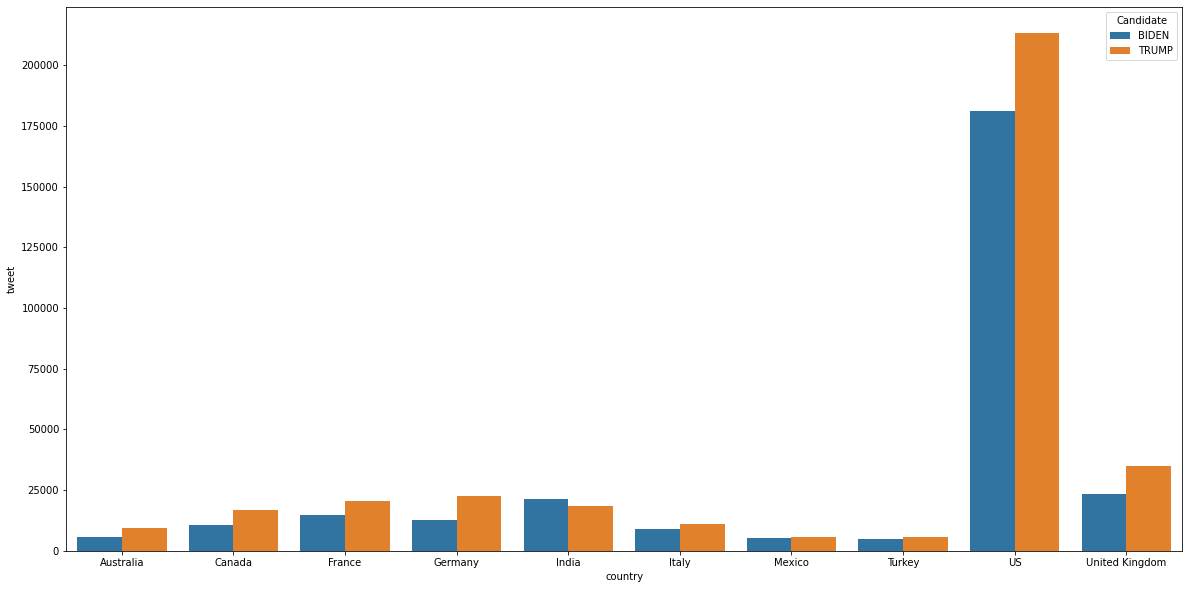

In [60]:
# Plot top 10 countries' number of tweets for each candidate
plt.figure(figsize=(20,10))
sns.barplot(data=tweet_df, x='country', y='tweet', hue='Candidate')
plt.show()

In [62]:
# List of top 10 states with highest number of Tweets
top10States = mixed_df.groupby('state')['tweet'].count().sort_values(ascending=False).head(10).index.tolist()
top10States

['California',
 'New York',
 'England',
 'Texas',
 'Florida',
 'District of Columbia',
 'Ile-de-France',
 'Pennsylvania',
 'Illinois',
 'Ontario']

In [73]:
state_df = mixed_df.groupby(['state', 'Candidate'])['tweet'].count().reset_index()
state_df = state_df[state_df['state'].isin(top10States)]
state_df

,state,Candidate,tweet
206,California,BIDEN,25817
207,California,TRUMP,31149
349,District of Columbia,BIDEN,7055
350,District of Columbia,TRUMP,9684
386,England,BIDEN,16743
387,England,TRUMP,24111
410,Florida,BIDEN,13284
411,Florida,TRUMP,16568
518,Ile-de-France,BIDEN,7001
519,Ile-de-France,TRUMP,9393


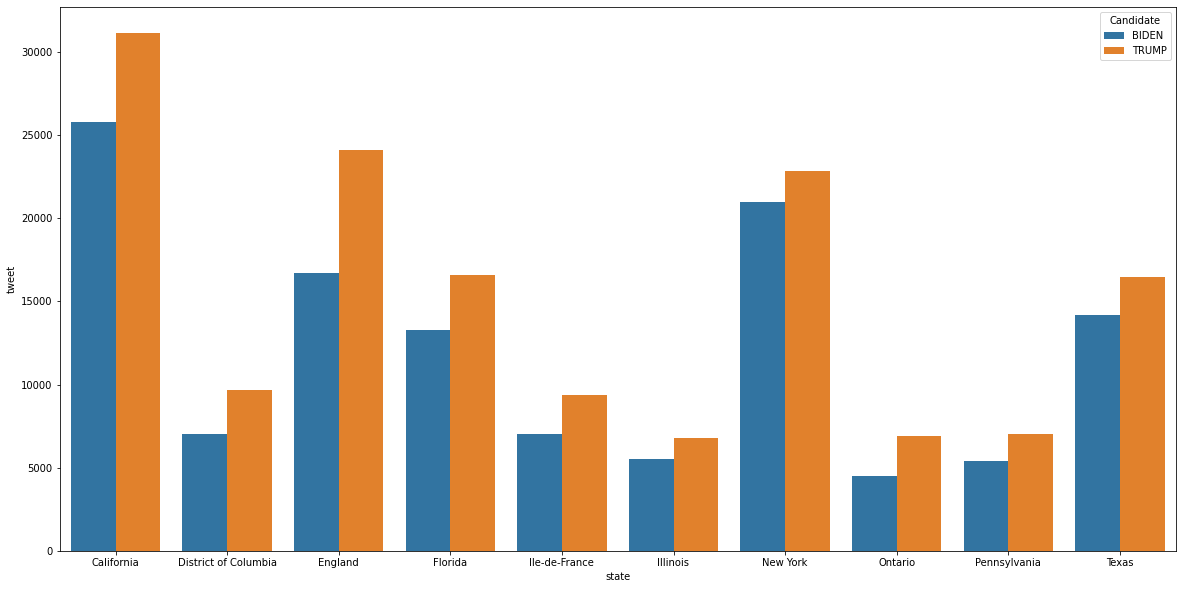

In [75]:
plt.figure(figsize=(20,10))
sns.barplot(data=state_df, x='state', y='tweet', hue='Candidate')
plt.show()

# Sentiment Analysis 

In [ ]:
def clean(text):
    '''Make text lowercase, remove text in square brackets, remove links, 
    remove punctuation and remove words containing numbers'''
    text = str(text).lower()
    